In [2]:
# input
metal_db_rep_tax_file = "../tmp/metaldb_repId-taxIds.tsv"
domain_lookup = "../tmp/taxId_domain.tsv"
# output
fig_file = "./fig/metaldb_pred_domain_venn.pdf"

In [3]:
import pandas as pd

df_lookup = pd.read_table(domain_lookup, header=None, names=['tax_id', "domain"])
lookup = dict(zip(df_lookup['tax_id'], df_lookup['domain']))
del df_lookup

df_metaldb = pd.read_table(metal_db_rep_tax_file , header=None, names=['rep_id', 'tax_ids'])
df_metaldb['domains'] = df_metaldb['tax_ids'].map(lambda x: ",".join(sorted(set([lookup[int(i)] for i in x.split() if int(i) in lookup]))))

In [4]:
from typing import Counter

data = Counter(df_metaldb['domains'])
data

Counter({'Bacteria': 4229676,
         'Eukaryota': 2675181,
         'Archaea': 337733,
         '': 127256,
         'Archaea,Bacteria': 33739,
         'Bacteria,Eukaryota': 11278,
         'Archaea,Bacteria,Eukaryota': 638,
         'Archaea,Eukaryota': 333})

<Figure size 240x240 with 0 Axes>

/home/zhangf/install/miniforge3/envs/metalnet-helper/lib/python3.11/site-packages/matplotlib_venn/_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


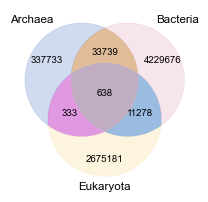

In [7]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3_unweighted

plt.style.use(f"{PROJECT_DIR}/asset/metalnet.mplstyle")
plt.figure(figsize=(2.4, 2.4))

subsets = {
    '100': 337733,    # Archaea only
    '010': 4229676,   # Bacteria only
    '001': 2675181,   # Eukaryota only
    '110': 33739,     # Archaea & Bacteria
    '101': 333,       # Archaea & Eukaryota
    '011': 11278,     # Bacteria & Eukaryota
    '111': 638        # All three
}

v = venn3_unweighted(
    subsets=subsets,
    set_labels=('Archaea', 'Bacteria', 'Eukaryota')
)

v.get_patch_by_id('100').set_color('#8CA6D9')
v.get_patch_by_id('010').set_color('#EDBFD1')
v.get_patch_by_id('001').set_color('#FAE5B3')


plt.savefig(fig_file, bbox_inches="tight", transparent=True)